In [1]:
import pandas as pd

print(pd.__version__)

3.0.5


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

print("Everything is working!")

Everything is working!


In [3]:
# Mumbai coordinates
latitude = 19.0760
longitude = 72.8777

# Open-Meteo historical weather API
url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={latitude}"
    f"&longitude={longitude}"
    f"&start_date=2015-01-01"
    f"&end_date=2025-12-31"
    f"&daily="
    f"temperature_2m_mean,"
    f"precipitation_sum,"
    f"wind_speed_10m_max,"
    f"pressure_msl_mean"
    f"&hourly=relative_humidity_2m"
    f"&timezone=auto"
)

response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


In [4]:
data = response.json()

daily_df = pd.DataFrame(data["daily"])

print("Dataset Shape:", daily_df.shape)

daily_df.head()

Dataset Shape: (4018, 5)


,time,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,pressure_msl_mean
0,2015-01-01,22.6,0.0,13.3,1009.5
1,2015-01-02,22.4,0.0,10.9,1012.0
2,2015-01-03,23.0,0.0,13.4,1013.7
3,2015-01-04,24.8,0.0,14.5,1013.6
4,2015-01-05,25.0,0.0,16.5,1013.2


In [5]:
hourly_df = pd.DataFrame(data["hourly"])

print("Shape:", hourly_df.shape)

hourly_df.head()

Shape: (96432, 2)


,time,relative_humidity_2m
0,2015-01-01T00:00,72
1,2015-01-01T01:00,73
2,2015-01-01T02:00,75
3,2015-01-01T03:00,77
4,2015-01-01T04:00,79


In [6]:
hourly_df["time"] = pd.to_datetime(hourly_df["time"])

hourly_df["date"] = hourly_df["time"].dt.date

daily_humidity = (
    hourly_df.groupby("date")["relative_humidity_2m"]
    .mean()
    .reset_index()
)

daily_humidity.head()

,date,relative_humidity_2m
0,2015-01-01,64.833333
1,2015-01-02,72.583333
2,2015-01-03,74.125000
3,2015-01-04,65.083333
4,2015-01-05,61.333333


In [7]:
daily_df["date"] = pd.to_datetime(daily_df["time"]).dt.date

daily_df = daily_df.merge(
    daily_humidity,
    on="date",
    how="left"
)

daily_df.head()

,time,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,pressure_msl_mean,date,relative_humidity_2m
0,2015-01-01,22.6,0.0,13.3,1009.5,2015-01-01,64.833333
1,2015-01-02,22.4,0.0,10.9,1012.0,2015-01-02,72.583333
2,2015-01-03,23.0,0.0,13.4,1013.7,2015-01-03,74.125000
3,2015-01-04,24.8,0.0,14.5,1013.6,2015-01-04,65.083333
4,2015-01-05,25.0,0.0,16.5,1013.2,2015-01-05,61.333333


In [8]:
daily_df = daily_df.rename(columns={
    "time": "date",
    "temperature_2m_mean": "temperature",
    "precipitation_sum": "rainfall",
    "wind_speed_10m_max": "wind_speed",
    "pressure_msl_mean": "pressure",
    "relative_humidity_2m": "humidity"
})

daily_df = daily_df.drop(columns=["date_y"], errors="ignore")

daily_df.head()

,date,temperature,rainfall,wind_speed,pressure,date,humidity
0,2015-01-01,22.6,0.0,13.3,1009.5,2015-01-01,64.833333
1,2015-01-02,22.4,0.0,10.9,1012.0,2015-01-02,72.583333
2,2015-01-03,23.0,0.0,13.4,1013.7,2015-01-03,74.125000
3,2015-01-04,24.8,0.0,14.5,1013.6,2015-01-04,65.083333
4,2015-01-05,25.0,0.0,16.5,1013.2,2015-01-05,61.333333


In [9]:
daily_df.columns

Index(['date', 'temperature', 'rainfall', 'wind_speed', 'pressure', 'date',
       'humidity'],
      dtype='str')

In [10]:
daily_df = daily_df.loc[:, ~daily_df.columns.duplicated()]

daily_df.columns

Index(['date', 'temperature', 'rainfall', 'wind_speed', 'pressure',
       'humidity'],
      dtype='str')

In [11]:
import pandas as pd

print(pd.__version__)

3.0.5


In [12]:
daily_df.isnull().sum()

date           0
temperature    0
rainfall       0
wind_speed     0
pressure       0
humidity       0
dtype: int64

In [14]:
import os

os.makedirs("../data/raw", exist_ok=True)

print("Folder created!")

Folder created!


In [15]:
daily_df.to_csv("../data/raw/mumbai_weather_2015_2025.csv", index=False)

print("Weather dataset saved successfully!")

Weather dataset saved successfully!


In [16]:
# Check the date range of our weather dataset

print("Start Date:", daily_df["date"].min())
print("End Date:", daily_df["date"].max())
print("Total Days:", len(daily_df))

Start Date: 2015-01-01
End Date: 2025-12-31
Total Days: 4018


In [17]:
print("Weather data ready for AQI integration.")
print("Rows:", len(daily_df))

Weather data ready for AQI integration.
Rows: 4018


In [18]:
# Mumbai coordinates
latitude = 19.0760
longitude = 72.8777

# Historical Air Quality API
aqi_url = (
    f"https://air-quality-api.open-meteo.com/v1/air-quality?"
    f"latitude={latitude}"
    f"&longitude={longitude}"
    f"&start_date=2015-01-01"
    f"&end_date=2025-12-31"
    f"&hourly=us_aqi"
    f"&timezone=auto"
)

aqi_response = requests.get(aqi_url)

print("Status Code:", aqi_response.status_code)

Status Code: 200


In [19]:
aqi_data = aqi_response.json()

aqi_hourly_df = pd.DataFrame(aqi_data["hourly"])

print("Shape:", aqi_hourly_df.shape)

aqi_hourly_df.head()

Shape: (96432, 2)


,time,us_aqi
0,2015-01-01T00:00,NaN
1,2015-01-01T01:00,NaN
2,2015-01-01T02:00,NaN
3,2015-01-01T03:00,NaN
4,2015-01-01T04:00,NaN


In [20]:
aqi_hourly_df["us_aqi"].isna().sum(), aqi_hourly_df["us_aqi"].notna().sum()

(np.int64(66557), np.int64(29875))

In [21]:
# Check available air-quality variables

print(aqi_data.keys())

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])


In [22]:
aqi_url = (
    f"https://air-quality-api.open-meteo.com/v1/air-quality?"
    f"latitude={latitude}"
    f"&longitude={longitude}"
    f"&start_date=2015-01-01"
    f"&end_date=2025-12-31"
    f"&hourly=us_aqi_pm2_5,pm2_5"
    f"&timezone=auto"
)

aqi_response = requests.get(aqi_url)

print("Status Code:", aqi_response.status_code)

Status Code: 200


In [23]:
aqi_data = aqi_response.json()

print(aqi_data["hourly"].keys())

dict_keys(['time', 'us_aqi_pm2_5', 'pm2_5'])


In [24]:
aqi_hourly_df = pd.DataFrame(aqi_data["hourly"])

print("Shape:", aqi_hourly_df.shape)

aqi_hourly_df.head()

Shape: (96432, 3)


,time,us_aqi_pm2_5,pm2_5
0,2015-01-01T00:00,NaN,NaN
1,2015-01-01T01:00,NaN,NaN
2,2015-01-01T02:00,NaN,NaN
3,2015-01-01T03:00,NaN,NaN
4,2015-01-01T04:00,NaN,NaN


In [25]:
print("Valid PM2.5:", aqi_hourly_df["pm2_5"].notna().sum())
print("Valid AQI:", aqi_hourly_df["us_aqi_pm2_5"].notna().sum())

Valid PM2.5: 29899
Valid AQI: 29875


In [26]:
valid_pm = aqi_hourly_df[aqi_hourly_df["pm2_5"].notna()].copy()

valid_pm["time"] = pd.to_datetime(valid_pm["time"])

print("First valid PM2.5:", valid_pm["time"].min())
print("Last valid PM2.5:", valid_pm["time"].max())
print("Valid records:", len(valid_pm))

First valid PM2.5: 2022-08-04 05:00:00
Last valid PM2.5: 2025-12-31 23:00:00
Valid records: 29899


In [27]:
valid_pm["date"] = valid_pm["time"].dt.date

daily_pm25 = (
    valid_pm.groupby("date")["pm2_5"]
    .mean()
    .reset_index()
)

daily_pm25.head()

,date,pm2_5
0,2022-08-04,25.989474
1,2022-08-05,16.737500
2,2022-08-06,18.979167
3,2022-08-07,17.841667
4,2022-08-08,18.375000


In [28]:
daily_df["date"] = pd.to_datetime(daily_df["date"]).dt.date

daily_df = daily_df.merge(
    daily_pm25,
    on="date",
    how="left"
)

daily_df.head()

,date,temperature,rainfall,wind_speed,pressure,humidity,pm2_5
0,2015-01-01,22.6,0.0,13.3,1009.5,64.833333,NaN
1,2015-01-02,22.4,0.0,10.9,1012.0,72.583333,NaN
2,2015-01-03,23.0,0.0,13.4,1013.7,74.125000,NaN
3,2015-01-04,24.8,0.0,14.5,1013.6,65.083333,NaN
4,2015-01-05,25.0,0.0,16.5,1013.2,61.333333,NaN


In [30]:
ml_df = daily_df.dropna(subset=["pm2_5"]).copy()

print("ML Dataset Shape:", ml_df.shape)
print("Start Date:", ml_df["date"].min())
print("End Date:", ml_df["date"].max())

ML Dataset Shape: (1246, 7)
Start Date: 2022-08-04
End Date: 2025-12-31


In [31]:
ml_df.columns

Index(['date', 'temperature', 'rainfall', 'wind_speed', 'pressure', 'humidity',
       'pm2_5'],
      dtype='str')

In [32]:
ml_df.to_csv("../data/processed/mumbai_climate_ml.csv", index=False)

print("Final ML dataset saved!")

OSError: Cannot save file into a non-existent directory: '..\data\processed'

In [33]:
import os

os.makedirs("../data/processed", exist_ok=True)

print("Processed folder created!")

Processed folder created!


In [34]:
ml_df.to_csv("../data/processed/mumbai_climate_ml.csv", index=False)

print("Final ML dataset saved!")

Final ML dataset saved!


In [36]:
ml_df.head()

,date,temperature,rainfall,wind_speed,pressure,humidity,pm2_5
2772,2022-08-04,27.0,13.6,13.3,1003.0,86.833333,25.989474
2773,2022-08-05,26.1,27.2,15.1,1001.6,90.250000,16.737500
2774,2022-08-06,26.1,33.7,17.1,1000.5,89.333333,18.979167
2775,2022-08-07,26.3,56.5,16.1,999.8,90.166667,17.841667
2776,2022-08-08,26.2,32.6,35.1,998.4,89.375000,18.375000


In [37]:
ml_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1246 entries, 2772 to 4017
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1246 non-null   object 
 1   temperature  1246 non-null   float64
 2   rainfall     1246 non-null   float64
 3   wind_speed   1246 non-null   float64
 4   pressure     1246 non-null   float64
 5   humidity     1246 non-null   float64
 6   pm2_5        1246 non-null   float64
dtypes: float64(6), object(1)
memory usage: 68.3+ KB


In [38]:
ml_df["date"] = pd.to_datetime(ml_df["date"])

ml_df["year"] = ml_df["date"].dt.year
ml_df["month"] = ml_df["date"].dt.month
ml_df["day"] = ml_df["date"].dt.day

ml_df.head()

,date,temperature,rainfall,wind_speed,pressure,humidity,pm2_5,year,month,day
2772,2022-08-04,27.0,13.6,13.3,1003.0,86.833333,25.989474,2022,8,4
2773,2022-08-05,26.1,27.2,15.1,1001.6,90.250000,16.737500,2022,8,5
2774,2022-08-06,26.1,33.7,17.1,1000.5,89.333333,18.979167,2022,8,6
2775,2022-08-07,26.3,56.5,16.1,999.8,90.166667,17.841667,2022,8,7
2776,2022-08-08,26.2,32.6,35.1,998.4,89.375000,18.375000,2022,8,8


In [39]:
ml_df["target_temperature"] = ml_df["temperature"].shift(-1)
ml_df["target_rainfall"] = ml_df["rainfall"].shift(-1)
ml_df["target_wind_speed"] = ml_df["wind_speed"].shift(-1)
ml_df["target_pressure"] = ml_df["pressure"].shift(-1)
ml_df["target_humidity"] = ml_df["humidity"].shift(-1)
ml_df["target_pm2_5"] = ml_df["pm2_5"].shift(-1)

ml_df = ml_df.dropna().copy()

print("Final ML rows:", len(ml_df))

Final ML rows: 1245


In [40]:
features = [
    "temperature",
    "rainfall",
    "wind_speed",
    "pressure",
    "humidity",
    "pm2_5",
    "year",
    "month",
    "day"
]

targets = [
    "target_temperature",
    "target_rainfall",
    "target_wind_speed",
    "target_pressure",
    "target_humidity",
    "target_pm2_5"
]

X = ml_df[features]
y = ml_df[targets]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1245, 9)
y shape: (1245, 6)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (996, 9)
Testing data: (249, 9)


In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [43]:
y_pred = model.predict(X_test)

print("Predictions shape:", y_pred.shape)

Predictions shape: (249, 6)


In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

target_names = [
    "Temperature",
    "Rainfall",
    "Wind Speed",
    "Pressure",
    "Humidity",
    "PM2.5"
]

for i, name in enumerate(target_names):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

    print(f"\n{name}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}")


Temperature
MAE  : 0.47
RMSE : 0.63
R²   : 0.82

Rainfall
MAE  : 8.06
RMSE : 16.60
R²   : 0.30

Wind Speed
MAE  : 2.46
RMSE : 3.20
R²   : 0.53

Pressure
MAE  : 0.78
RMSE : 1.02
R²   : 0.93

Humidity
MAE  : 2.92
RMSE : 4.04
R²   : 0.93

PM2.5
MAE  : 5.39
RMSE : 7.14
R²   : 0.84


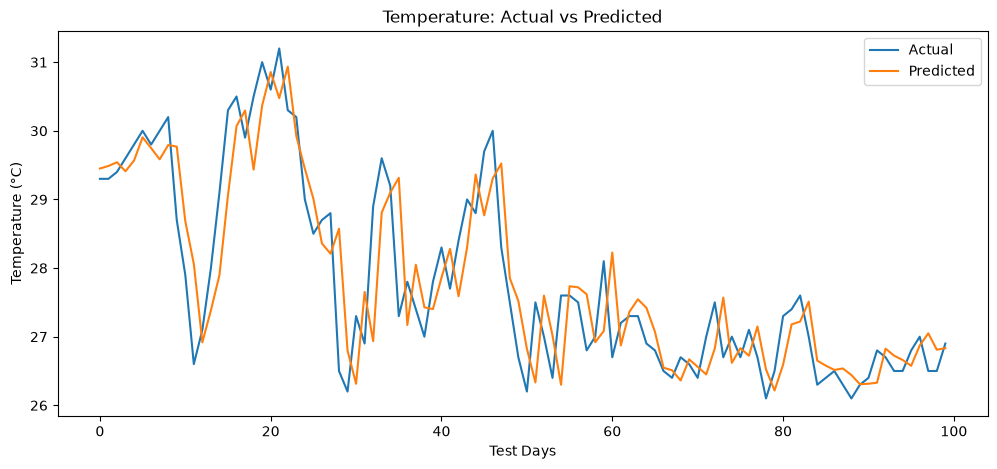

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    y_test["target_temperature"].values[:100],
    label="Actual"
)

plt.plot(
    y_pred[:100, 0],
    label="Predicted"
)

plt.title("Temperature: Actual vs Predicted")
plt.xlabel("Test Days")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

In [47]:
import joblib

joblib.dump(model, "../models/mumbai_climate_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [48]:
# Take the latest available day
latest = ml_df.iloc[-1]

# Create input for prediction
latest_input = pd.DataFrame([[
    latest["temperature"],
    latest["rainfall"],
    latest["wind_speed"],
    latest["pressure"],
    latest["humidity"],
    latest["pm2_5"],
    latest["year"],
    latest["month"],
    latest["day"]
]], columns=features)

# Predict next day
prediction = model.predict(latest_input)[0]

print("Predicted values for next day:")
print("Temperature :", round(prediction[0], 2), "°C")
print("Rainfall    :", round(prediction[1], 2), "mm")
print("Wind Speed  :", round(prediction[2], 2), "km/h")
print("Pressure    :", round(prediction[3], 2), "hPa")
print("Humidity    :", round(prediction[4], 2), "%")
print("PM2.5       :", round(prediction[5], 2), "µg/m³")

Predicted values for next day:
Temperature : 24.04 °C
Rainfall    : 0.0 mm
Wind Speed  : 13.39 km/h
Pressure    : 1013.55 hPa
Humidity    : 59.53 %
PM2.5       : 65.82 µg/m³


In [49]:
import joblib

joblib.dump(model, "../models/mumbai_climate_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [4]:
import pandas as pd

ml_df = pd.read_csv("../data/processed/mumbai_climate_ml.csv")

print("Dataset loaded:", ml_df.shape)

Dataset loaded: (1246, 7)


In [5]:
ml_df["date"] = pd.to_datetime(ml_df["date"])

ml_df["year"] = ml_df["date"].dt.year
ml_df["month"] = ml_df["date"].dt.month
ml_df["day"] = ml_df["date"].dt.day

ml_df["target_temperature"] = ml_df["temperature"].shift(-1)
ml_df["target_rainfall"] = ml_df["rainfall"].shift(-1)
ml_df["target_wind_speed"] = ml_df["wind_speed"].shift(-1)
ml_df["target_pressure"] = ml_df["pressure"].shift(-1)
ml_df["target_humidity"] = ml_df["humidity"].shift(-1)
ml_df["target_pm2_5"] = ml_df["pm2_5"].shift(-1)

ml_df = ml_df.dropna().copy()

print("Final ML dataset:", ml_df.shape)

Final ML dataset: (1245, 16)


In [6]:
features = [
    "temperature",
    "rainfall",
    "wind_speed",
    "pressure",
    "humidity",
    "pm2_5",
    "year",
    "month",
    "day"
]

targets = [
    "target_temperature",
    "target_rainfall",
    "target_wind_speed",
    "target_pressure",
    "target_humidity",
    "target_pm2_5"
]

X = ml_df[features]
y = ml_df[targets]

print("X:", X.shape)
print("y:", y.shape)

X: (1245, 9)
y: (1245, 6)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (996, 9)
Testing: (249, 9)


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
)

model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [10]:
import joblib

joblib.dump(model, "../models/mumbai_climate_model.pkl")

print("Final Random Forest model saved!")

Final Random Forest model saved!


In [11]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor

extra_model = MultiOutputRegressor(
    ExtraTreesRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
)

extra_model.fit(X_train, y_train)

print("Extra Trees training completed!")

Extra Trees training completed!


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

extra_pred = extra_model.predict(X_test)

target_names = [
    "Temperature",
    "Rainfall",
    "Wind Speed",
    "Pressure",
    "Humidity",
    "PM2.5"
]

for i, name in enumerate(target_names):

    mae = mean_absolute_error(
        y_test.iloc[:, i],
        extra_pred[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test.iloc[:, i],
            extra_pred[:, i]
        )
    )

    r2 = r2_score(
        y_test.iloc[:, i],
        extra_pred[:, i]
    )

    print(f"\n{name}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}")


Temperature
MAE  : 0.48
RMSE : 0.64
R²   : 0.81

Rainfall
MAE  : 7.90
RMSE : 16.23
R²   : 0.33

Wind Speed
MAE  : 2.44
RMSE : 3.14
R²   : 0.55

Pressure
MAE  : 0.80
RMSE : 1.02
R²   : 0.93

Humidity
MAE  : 3.13
RMSE : 4.13
R²   : 0.93

PM2.5
MAE  : 5.19
RMSE : 6.92
R²   : 0.85


In [13]:
import joblib

joblib.dump(
    extra_model,
    "../models/mumbai_climate_model.pkl"
)

print("Extra Trees model saved as final model!")

Extra Trees model saved as final model!


In [2]:
import pandas as pd

ml_df = pd.read_csv("../data/processed/mumbai_climate_ml.csv")

print(ml_df.shape)
print(ml_df.columns)

(1246, 7)
Index(['date', 'temperature', 'rainfall', 'wind_speed', 'pressure', 'humidity',
       'pm2_5'],
      dtype='str')


In [3]:
ml_df["date"] = pd.to_datetime(ml_df["date"])

ml_df["year"] = ml_df["date"].dt.year
ml_df["month"] = ml_df["date"].dt.month
ml_df["day"] = ml_df["date"].dt.day

ml_df["target_temperature"] = ml_df["temperature"].shift(-1)
ml_df["target_rainfall"] = ml_df["rainfall"].shift(-1)
ml_df["target_wind_speed"] = ml_df["wind_speed"].shift(-1)
ml_df["target_pressure"] = ml_df["pressure"].shift(-1)
ml_df["target_humidity"] = ml_df["humidity"].shift(-1)
ml_df["target_pm2_5"] = ml_df["pm2_5"].shift(-1)

ml_df = ml_df.dropna().copy()

print("Final ML dataset:", ml_df.shape)

Final ML dataset: (1245, 16)


In [4]:
features = [
    "temperature",
    "rainfall",
    "wind_speed",
    "pressure",
    "humidity",
    "pm2_5",
    "year",
    "month",
    "day"
]

targets = [
    "target_temperature",
    "target_rainfall",
    "target_wind_speed",
    "target_pressure",
    "target_humidity",
    "target_pm2_5"
]

X = ml_df[features]
y = ml_df[targets]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1245, 9)
y shape: (1245, 6)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (996, 9)
Testing: (249, 9)


In [6]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

gb_model = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting training completed!")

Gradient Boosting training completed!


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb_pred = gb_model.predict(X_test)

target_names = [
    "Temperature",
    "Rainfall",
    "Wind Speed",
    "Pressure",
    "Humidity",
    "PM2.5"
]

for i, name in enumerate(target_names):

    mae = mean_absolute_error(
        y_test.iloc[:, i],
        gb_pred[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test.iloc[:, i],
            gb_pred[:, i]
        )
    )

    r2 = r2_score(
        y_test.iloc[:, i],
        gb_pred[:, i]
    )

    print(f"\n{name}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}")


Temperature
MAE  : 0.45
RMSE : 0.60
R²   : 0.83

Rainfall
MAE  : 7.40
RMSE : 16.37
R²   : 0.31

Wind Speed
MAE  : 2.36
RMSE : 3.10
R²   : 0.56

Pressure
MAE  : 0.77
RMSE : 1.01
R²   : 0.93

Humidity
MAE  : 3.30
RMSE : 4.34
R²   : 0.92

PM2.5
MAE  : 4.43
RMSE : 6.49
R²   : 0.87


In [8]:
import pandas as pd

weather_df = pd.read_csv("../data/processed/mumbai_climate_ml.csv")

weather_df["date"] = pd.to_datetime(weather_df["date"])

weather_df = weather_df.sort_values("date").reset_index(drop=True)

print("Dataset shape:", weather_df.shape)
print("Date range:", weather_df["date"].min(), "to", weather_df["date"].max())

Dataset shape: (1246, 7)
Date range: 2022-08-04 00:00:00 to 2025-12-31 00:00:00


In [9]:
# ============================================================
# STEP 1B — LAG FEATURES
# ============================================================

lag_columns = [
    "temperature",
    "rainfall",
    "wind_speed",
    "pressure",
    "humidity",
    "pm2_5"
]

for column in lag_columns:
    weather_df[f"{column}_lag_1"] = weather_df[column].shift(1)

print("Lag features created!")
print(weather_df.columns.tolist())

Lag features created!
['date', 'temperature', 'rainfall', 'wind_speed', 'pressure', 'humidity', 'pm2_5', 'temperature_lag_1', 'rainfall_lag_1', 'wind_speed_lag_1', 'pressure_lag_1', 'humidity_lag_1', 'pm2_5_lag_1']


In [10]:
# ============================================================
# STEP 1C — ROLLING AVERAGE FEATURES
# ============================================================

rolling_columns = [
    "temperature",
    "rainfall",
    "humidity",
    "pm2_5"
]

for column in rolling_columns:

    weather_df[f"{column}_rolling_3"] = (
        weather_df[column]
        .rolling(window=3)
        .mean()
    )

    weather_df[f"{column}_rolling_7"] = (
        weather_df[column]
        .rolling(window=7)
        .mean()
    )

print("Rolling average features created!")

print(weather_df.columns.tolist())


Rolling average features created!
['date', 'temperature', 'rainfall', 'wind_speed', 'pressure', 'humidity', 'pm2_5', 'temperature_lag_1', 'rainfall_lag_1', 'wind_speed_lag_1', 'pressure_lag_1', 'humidity_lag_1', 'pm2_5_lag_1', 'temperature_rolling_3', 'temperature_rolling_7', 'rainfall_rolling_3', 'rainfall_rolling_7', 'humidity_rolling_3', 'humidity_rolling_7', 'pm2_5_rolling_3', 'pm2_5_rolling_7']


In [11]:
# ============================================================
# STEP 1D — SEASONALITY FEATURES
# ============================================================

import numpy as np

weather_df["day_of_year"] = weather_df["date"].dt.dayofyear

weather_df["sin_day_of_year"] = np.sin(
    2 * np.pi * weather_df["day_of_year"] / 365.25
)

weather_df["cos_day_of_year"] = np.cos(
    2 * np.pi * weather_df["day_of_year"] / 365.25
)

print("Seasonality features created!")

print(
    weather_df[
        [
            "date",
            "day_of_year",
            "sin_day_of_year",
            "cos_day_of_year"
        ]
    ].head()
)

Seasonality features created!
        date  day_of_year  sin_day_of_year  cos_day_of_year
0 2022-08-04          216        -0.543105        -0.839665
1 2022-08-05          217        -0.557468        -0.830198
2 2022-08-06          218        -0.571667        -0.820486
3 2022-08-07          219        -0.585696        -0.810531
4 2022-08-08          220        -0.599551        -0.800336


In [12]:
# ============================================================
# STEP 1E — CLEAN & VALIDATE FEATURE-ENGINEERED DATASET
# ============================================================

print("Missing values before cleaning:")
print(weather_df.isnull().sum())

# Remove rows affected by lag/rolling calculations
weather_df = weather_df.dropna().reset_index(drop=True)

print("\nMissing values after cleaning:")
print(weather_df.isnull().sum())

print("\nFinal feature-engineered dataset shape:")
print(weather_df.shape)

print("\nDate range:")
print(weather_df["date"].min(), "to", weather_df["date"].max())

Missing values before cleaning:
date                     0
temperature              0
rainfall                 0
wind_speed               0
pressure                 0
humidity                 0
pm2_5                    0
temperature_lag_1        1
rainfall_lag_1           1
wind_speed_lag_1         1
pressure_lag_1           1
humidity_lag_1           1
pm2_5_lag_1              1
temperature_rolling_3    2
temperature_rolling_7    6
rainfall_rolling_3       2
rainfall_rolling_7       6
humidity_rolling_3       2
humidity_rolling_7       6
pm2_5_rolling_3          2
pm2_5_rolling_7          6
day_of_year              0
sin_day_of_year          0
cos_day_of_year          0
dtype: int64

Missing values after cleaning:
date                     0
temperature              0
rainfall                 0
wind_speed               0
pressure                 0
humidity                 0
pm2_5                    0
temperature_lag_1        0
rainfall_lag_1           0
wind_speed_lag_1         0
press

In [13]:
# ============================================================
# STEP 1F — CREATE NEXT-DAY TARGETS
# ============================================================

target_columns = [
    "temperature",
    "rainfall",
    "wind_speed",
    "pressure",
    "humidity",
    "pm2_5"
]

for column in target_columns:
    weather_df[f"target_{column}"] = weather_df[column].shift(-1)

# Remove the final row because it has no next-day target
weather_df = weather_df.dropna().reset_index(drop=True)

print("Next-day targets created!")

print("\nDataset shape:")
print(weather_df.shape)

print("\nTarget columns:")
print([
    column for column in weather_df.columns
    if column.startswith("target_")
])

Next-day targets created!

Dataset shape:
(1239, 30)

Target columns:
['target_temperature', 'target_rainfall', 'target_wind_speed', 'target_pressure', 'target_humidity', 'target_pm2_5']


In [14]:
# ============================================================
# STEP 2A — DEFINE FEATURES AND TARGETS
# ============================================================

features = [
    # Today's climate
    "temperature",
    "rainfall",
    "wind_speed",
    "pressure",
    "humidity",
    "pm2_5",

    # Previous day's climate
    "temperature_lag_1",
    "rainfall_lag_1",
    "wind_speed_lag_1",
    "pressure_lag_1",
    "humidity_lag_1",
    "pm2_5_lag_1",

    # Recent trends
    "temperature_rolling_3",
    "temperature_rolling_7",
    "rainfall_rolling_3",
    "rainfall_rolling_7",
    "humidity_rolling_3",
    "humidity_rolling_7",
    "pm2_5_rolling_3",
    "pm2_5_rolling_7",

    # Seasonality
    "day_of_year",
    "sin_day_of_year",
    "cos_day_of_year"
]

targets = [
    "target_temperature",
    "target_rainfall",
    "target_wind_speed",
    "target_pressure",
    "target_humidity",
    "target_pm2_5"
]

X = weather_df[features]
y = weather_df[targets]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1239, 23)
y shape: (1239, 6)


In [15]:

# ============================================================
# STEP 2B — TIME-BASED TRAIN / TEST SPLIT
# ============================================================

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training X:", X_train.shape)
print("Testing X :", X_test.shape)

print("Training y:", y_train.shape)
print("Testing y :", y_test.shape)

print("\nTraining period:")
print(weather_df["date"].iloc[:split_index].min(),
      "to",
      weather_df["date"].iloc[:split_index].max())

print("\nTesting period:")
print(weather_df["date"].iloc[split_index:].min(),
      "to",
      weather_df["date"].iloc[-1])

Training X: (991, 23)
Testing X : (248, 23)
Training y: (991, 6)
Testing y : (248, 6)

Training period:
2022-08-10 00:00:00 to 2025-04-26 00:00:00

Testing period:
2025-04-27 00:00:00 to 2025-12-30 00:00:00


In [16]:
# ============================================================
# STEP 3 — EXTRA TREES WITH FEATURE ENGINEERING
# ============================================================

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor

extra_fe_model = MultiOutputRegressor(
    ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
)

extra_fe_model.fit(X_train, y_train)

print("Extra Trees with feature engineering trained!")

Extra Trees with feature engineering trained!


In [17]:
# ============================================================
# STEP 3B — EVALUATE EXTRA TREES WITH FEATURE ENGINEERING
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

extra_fe_pred = extra_fe_model.predict(X_test)

target_names = [
    "Temperature",
    "Rainfall",
    "Wind Speed",
    "Pressure",
    "Humidity",
    "PM2.5"
]

for i, name in enumerate(target_names):

    mae = mean_absolute_error(
        y_test.iloc[:, i],
        extra_fe_pred[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test.iloc[:, i],
            extra_fe_pred[:, i]
        )
    )

    r2 = r2_score(
        y_test.iloc[:, i],
        extra_fe_pred[:, i]
    )

    print(f"\n{name}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}")


Temperature
MAE  : 0.46
RMSE : 0.62
R²   : 0.82

Rainfall
MAE  : 7.84
RMSE : 16.27
R²   : 0.33

Wind Speed
MAE  : 2.59
RMSE : 3.32
R²   : 0.50

Pressure
MAE  : 0.80
RMSE : 1.02
R²   : 0.93

Humidity
MAE  : 2.97
RMSE : 4.05
R²   : 0.93

PM2.5
MAE  : 4.68
RMSE : 6.55
R²   : 0.87


In [18]:
# ============================================================
# STEP 3C — GRADIENT BOOSTING WITH FEATURE ENGINEERING
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

gb_fe_model = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
)

gb_fe_model.fit(X_train, y_train)

print("Gradient Boosting with feature engineering trained!")

Gradient Boosting with feature engineering trained!


In [19]:
# ============================================================
# STEP 3D — EVALUATE GRADIENT BOOSTING WITH FEATURE ENGINEERING
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb_fe_pred = gb_fe_model.predict(X_test)

target_names = [
    "Temperature",
    "Rainfall",
    "Wind Speed",
    "Pressure",
    "Humidity",
    "PM2.5"
]

for i, name in enumerate(target_names):

    mae = mean_absolute_error(
        y_test.iloc[:, i],
        gb_fe_pred[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test.iloc[:, i],
            gb_fe_pred[:, i]
        )
    )

    r2 = r2_score(
        y_test.iloc[:, i],
        gb_fe_pred[:, i]
    )

    print(f"\n{name}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}")


Temperature
MAE  : 0.44
RMSE : 0.60
R²   : 0.83

Rainfall
MAE  : 7.21
RMSE : 15.90
R²   : 0.36

Wind Speed
MAE  : 2.51
RMSE : 3.24
R²   : 0.52

Pressure
MAE  : 0.80
RMSE : 1.06
R²   : 0.93

Humidity
MAE  : 3.09
RMSE : 4.23
R²   : 0.93

PM2.5
MAE  : 4.71
RMSE : 6.81
R²   : 0.86


In [20]:
# ============================================================
# STEP 4 — MODEL COMPARISON TABLE
# ============================================================

comparison_data = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting",
        "Extra Trees + Features",
        "Gradient Boosting + Features"
    ],
    "Temperature_R2": [0.82, 0.81, 0.83, 0.82, 0.83],
    "Rainfall_R2": [0.30, 0.33, 0.31, 0.33, 0.36],
    "Wind_R2": [0.53, 0.55, 0.56, 0.50, 0.52],
    "Pressure_R2": [0.93, 0.93, 0.93, 0.93, 0.93],
    "Humidity_R2": [0.93, 0.93, 0.92, 0.93, 0.93],
    "PM2.5_R2": [0.84, 0.85, 0.87, 0.87, 0.86]
})

comparison_data["Average_R2"] = comparison_data[
    [
        "Temperature_R2",
        "Rainfall_R2",
        "Wind_R2",
        "Pressure_R2",
        "Humidity_R2",
        "PM2.5_R2"
    ]
].mean(axis=1)

comparison_data = comparison_data.sort_values(
    "Average_R2",
    ascending=False
).reset_index(drop=True)

print(comparison_data.round(3))

                          Model  Temperature_R2  Rainfall_R2  Wind_R2  \
0  Gradient Boosting + Features            0.83         0.36     0.52   
1             Gradient Boosting            0.83         0.31     0.56   
2                   Extra Trees            0.81         0.33     0.55   
3        Extra Trees + Features            0.82         0.33     0.50   
4                 Random Forest            0.82         0.30     0.53   

   Pressure_R2  Humidity_R2  PM2.5_R2  Average_R2  
0         0.93         0.93      0.86       0.738  
1         0.93         0.92      0.87       0.737  
2         0.93         0.93      0.85       0.733  
3         0.93         0.93      0.87       0.730  
4         0.93         0.93      0.84       0.725  


In [21]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.0


In [22]:
# ============================================================
# STEP 5A — XGBOOST WITH FEATURE ENGINEERING
# ============================================================

from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

xgb_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
)

xgb_model.fit(X_train, y_train)

print("XGBoost with feature engineering trained!")

XGBoost with feature engineering trained!


In [23]:
# ============================================================
# STEP 5B — EVALUATE XGBOOST
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_pred = xgb_model.predict(X_test)

target_names = [
    "Temperature",
    "Rainfall",
    "Wind Speed",
    "Pressure",
    "Humidity",
    "PM2.5"
]

for i, name in enumerate(target_names):

    mae = mean_absolute_error(
        y_test.iloc[:, i],
        xgb_pred[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test.iloc[:, i],
            xgb_pred[:, i]
        )
    )

    r2 = r2_score(
        y_test.iloc[:, i],
        xgb_pred[:, i]
    )

    print(f"\n{name}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}")


Temperature
MAE  : 0.45
RMSE : 0.60
R²   : 0.83

Rainfall
MAE  : 7.37
RMSE : 16.18
R²   : 0.33

Wind Speed
MAE  : 2.46
RMSE : 3.18
R²   : 0.54

Pressure
MAE  : 0.83
RMSE : 1.07
R²   : 0.92

Humidity
MAE  : 3.00
RMSE : 4.14
R²   : 0.93

PM2.5
MAE  : 4.83
RMSE : 6.92
R²   : 0.85


In [24]:
# ============================================================
# STEP 6 — SAVE FINAL GRADIENT BOOSTING MODEL
# ============================================================

import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    gb_fe_model,
    "../models/mumbai_climate_model.pkl"
)

joblib.dump(
    features,
    "../models/mumbai_climate_features.pkl"
)

print("Final Gradient Boosting model saved!")
print("Feature list saved!")

Final Gradient Boosting model saved!
Feature list saved!


In [25]:
# ============================================================
# STEP 6B — TEST PREPROCESSING PIPELINE
# ============================================================

import sys

sys.path.append("../src")

from preprocessing import create_features

# Load original clean dataset
test_df = pd.read_csv("../data/processed/mumbai_climate_ml.csv")

# Create engineered features
test_features = create_features(test_df)

print("Feature engineering successful!")
print("Dataset shape:", test_features.shape)

print("\nFeature columns:")
print(test_features.columns.tolist())

Feature engineering successful!
Dataset shape: (1246, 24)

Feature columns:
['date', 'temperature', 'rainfall', 'wind_speed', 'pressure', 'humidity', 'pm2_5', 'temperature_lag_1', 'rainfall_lag_1', 'wind_speed_lag_1', 'pressure_lag_1', 'humidity_lag_1', 'pm2_5_lag_1', 'temperature_rolling_3', 'temperature_rolling_7', 'rainfall_rolling_3', 'rainfall_rolling_7', 'humidity_rolling_3', 'humidity_rolling_7', 'pm2_5_rolling_3', 'pm2_5_rolling_7', 'day_of_year', 'sin_day_of_year', 'cos_day_of_year']


In [26]:
# ============================================================
# STEP 6C — VERIFY SAVED MODEL FEATURES
# ============================================================

import joblib

saved_features = joblib.load(
    "../models/mumbai_climate_features.pkl"
)

print("Number of saved features:", len(saved_features))

print("\nSaved features:")
for i, feature in enumerate(saved_features, start=1):
    print(f"{i:2}. {feature}")

Number of saved features: 23

Saved features:
 1. temperature
 2. rainfall
 3. wind_speed
 4. pressure
 5. humidity
 6. pm2_5
 7. temperature_lag_1
 8. rainfall_lag_1
 9. wind_speed_lag_1
10. pressure_lag_1
11. humidity_lag_1
12. pm2_5_lag_1
13. temperature_rolling_3
14. temperature_rolling_7
15. rainfall_rolling_3
16. rainfall_rolling_7
17. humidity_rolling_3
18. humidity_rolling_7
19. pm2_5_rolling_3
20. pm2_5_rolling_7
21. day_of_year
22. sin_day_of_year
23. cos_day_of_year


In [27]:
# ============================================================
# STEP 6E — TEST PREDICTION FEATURE PIPELINE
# ============================================================

import joblib
import pandas as pd
import sys

sys.path.append("../src")

from preprocessing import prepare_prediction_features

# Load historical data
prediction_df = pd.read_csv(
    "../data/processed/mumbai_climate_ml.csv"
)

# Load the exact features used by the final model
saved_features = joblib.load(
    "../models/mumbai_climate_features.pkl"
)

# Prepare latest prediction features
X_latest = prepare_prediction_features(
    prediction_df,
    saved_features
)

print("Prediction features created successfully!")
print("Shape:", X_latest.shape)

print("\nFeatures:")
print(X_latest.columns.tolist())

print("\nLatest input values:")
print(X_latest)

ImportError: cannot import name 'prepare_prediction_features' from 'preprocessing' (D:\Mumbai-Climate-Prediction\notebooks\../src\preprocessing.py)

In [28]:
# Reload the preprocessing module

import sys
import importlib

sys.path.append("../src")

import preprocessing

importlib.reload(preprocessing)

from preprocessing import prepare_prediction_features

print("preprocessing.py reloaded successfully!")

preprocessing.py reloaded successfully!


In [29]:
import joblib
import pandas as pd

prediction_df = pd.read_csv(
    "../data/processed/mumbai_climate_ml.csv"
)

saved_features = joblib.load(
    "../models/mumbai_climate_features.pkl"
)

X_latest = prepare_prediction_features(
    prediction_df,
    saved_features
)

print("Prediction features created successfully!")
print("Shape:", X_latest.shape)
print("\nNumber of features:", len(X_latest.columns))

Prediction features created successfully!
Shape: (1, 23)

Number of features: 23


In [30]:
final_model = joblib.load(
    "../models/mumbai_climate_model.pkl"
)

prediction = final_model.predict(X_latest)[0]

target_names = [
    "Temperature",
    "Rainfall",
    "Wind Speed",
    "Pressure",
    "Humidity",
    "PM2.5"
]

print("Tomorrow's predicted climate:")

for name, value in zip(target_names, prediction):
    print(f"{name:<12}: {value:.2f}")

Tomorrow's predicted climate:
Temperature : 23.66
Rainfall    : 0.22
Wind Speed  : 13.57
Pressure    : 1012.14
Humidity    : 67.55
PM2.5       : 65.02


In [31]:
# ============================================================
# STEP 7A — TEST TODAY'S CLIMATE INPUT
# ============================================================

import joblib
import pandas as pd
import sys

# Reload preprocessing module
sys.path.append("../src")

import preprocessing
import importlib

importlib.reload(preprocessing)

from preprocessing import prepare_prediction_features

# Load historical data
prediction_df = pd.read_csv(
    "../data/processed/mumbai_climate_ml.csv"
)

# Load exact model feature list
saved_features = joblib.load(
    "../models/mumbai_climate_features.pkl"
)

# ------------------------------------------------------------
# Simulated TODAY'S climate data
# ------------------------------------------------------------

today_temperature = 27.0
today_rainfall = 2.0
today_wind_speed = 15.0
today_pressure = 1010.0
today_humidity = 75.0
today_pm2_5 = 40.0

prediction_date = "2026-08-14"

# ------------------------------------------------------------
# Create prediction features
# ------------------------------------------------------------

X_today = prepare_prediction_features(
    prediction_df,
    saved_features,
    today_temperature,
    today_rainfall,
    today_wind_speed,
    today_pressure,
    today_humidity,
    today_pm2_5,
    prediction_date
)

print("Today's prediction features created successfully!")
print("Shape:", X_today.shape)

print("\nToday's values used:")
print("Temperature:", today_temperature)
print("Rainfall:", today_rainfall)
print("Wind Speed:", today_wind_speed)
print("Pressure:", today_pressure)
print("Humidity:", today_humidity)
print("PM2.5:", today_pm2_5)

print("\nModel input:")
print(X_today)

Today's prediction features created successfully!
Shape: (1, 23)

Today's values used:
Temperature: 27.0
Rainfall: 2.0
Wind Speed: 15.0
Pressure: 1010.0
Humidity: 75.0
PM2.5: 40.0

Model input:
      temperature  rainfall  wind_speed  pressure  humidity  pm2_5  \
1246         27.0       2.0        15.0    1010.0      75.0   40.0   

      temperature_lag_1  rainfall_lag_1  wind_speed_lag_1  pressure_lag_1  \
1246               23.2             0.0              13.4          1011.9   

      ...  temperature_rolling_7  rainfall_rolling_3  rainfall_rolling_7  \
1246  ...                   24.7            0.666667            0.285714   

      humidity_rolling_3  humidity_rolling_7  pm2_5_rolling_3  \
1246           69.944444           57.702381        52.844444   

      pm2_5_rolling_7  day_of_year  sin_day_of_year  cos_day_of_year  
1246        57.644048          226         -0.67882        -0.734304  

[1 rows x 23 columns]


In [32]:
# ============================================================
# STEP 7B — ACTUAL TOMORROW PREDICTION
# ============================================================

import joblib

# Load final trained model
final_model = joblib.load(
    "../models/mumbai_climate_model.pkl"
)

# Generate prediction
prediction = final_model.predict(X_today)[0]

target_names = [
    "Temperature",
    "Rainfall",
    "Wind Speed",
    "Pressure",
    "Humidity",
    "PM2.5"
]

print("Tomorrow's predicted climate:")

for name, value in zip(target_names, prediction):
    print(f"{name:<12}: {value:.2f}")

Tomorrow's predicted climate:
Temperature : 27.02
Rainfall    : 0.22
Wind Speed  : 16.12
Pressure    : 1009.47
Humidity    : 74.87
PM2.5       : 40.77
